# Restaurant Marketing Prioritisation Pipeline

**Objective:** Ranked list of restaurants to market, based on growth trajectory with full seasonality transparency.

**Inputs:**
- `restaurants_agg_performance.parquet` â€” from `momentum_seasonality.ipynb`
- `activity_performance_with_roi.csv` â€” from `compare_bookings_with_marketing.ipynb`

**Output:** `priority_list.csv`

---

## Scoring logic

### Step 1 â€” Stability filter
Must have positive MoM booking growth in **5 of the last 6 months** (absolute test, not relative rank).
Seasonal restaurants (pass MoM filter but weak YoY) are **included** but tagged.

### Step 2 â€” Growth signal selection (computed in momentum notebook)
| Condition | Signal used |
|---|---|
| `has_full_year=True` AND `booking_growth_yoy_rolling` not NaN (â‰¥2 of 3 months valid) | YoY 70% + MoM 30% |
| otherwise | MoM 100% |

### Step 3 â€” Priority score
```
# Blended raw rate (done in momentum notebook, already in parquet as growth_rate_blended)
growth_rate_blended = yoy_raw Ã— 0.70 + mom_raw Ã— 0.30   (if YoY valid)
                    = mom_raw                             (otherwise)

# score_growth = min_max(growth_rate_blended)   â† single normalisation, all restaurants same scale

growth_component = score_growth_norm Ã— 0.60 + delta_growth_norm Ã— 0.40
priority_score   = min_max_norm(growth_component) Ã— 100
```

Marketing history informs **tier labels and channel recommendations only** â€” it does not affect the score.

## 0) Configuration & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')

# ── Paths ─────────────────────────────────────────────────────────────────────
MOMENTUM_PATH  = Path('../_2_feature_engineering+momentum/start/restaurants_agg_performance.parquet')
MARKETING_PATH = Path('../_3_marketing/activity_performance_with_roi.csv')
OUTPUT_PATH    = Path('priority_list.csv')
SEGMENT_OUTPUT_PATH = Path('../_2_feature_engineering+momentum/start/priority_latest_momentum_labels.parquet')

# ── Stability filter ──────────────────────────────────────────────────────────
LOOKBACK_MONTHS   = 3   # look back N months for segment stability
MIN_GROWTH_MONTHS = 3   # must appear in a growth segment in at least this many months

GROWTH_SEGMENTS = ['Rising Stars', 'Emerging Opportunities']

# ── Score weights ─────────────────────────────────────────────────────────────
# Growth component (used for ALL restaurants)
W_SCORE_GROWTH = 0.50   # rolling growth trajectory
W_DELTA_GROWTH = 0.50   # acceleration (is growth speeding up?)

# Marketing component (used ONLY for restaurants with marketing history)
W_GROWTH_FINAL    = 0.60  # weight of growth component in final score
W_MARKETING_FINAL = 0.40  # weight of marketing component in final score
W_LIFT = 0.60             # avg lift per day within marketing component
W_ROI  = 0.40             # avg roi within marketing component

print('Configuration loaded.')


Configuration loaded.


## 1) Helper Functions

In [2]:
def min_max_norm(s: pd.Series) -> pd.Series:
    """Normalise a series to [0, 1]. Returns 0.5 uniformly if all values identical."""
    rng = s.max() - s.min()
    if rng == 0:
        return pd.Series(0.5, index=s.index)
    return (s - s.min()) / rng


def get_segment(row, perf_threshold, growth_threshold):
    """Assign 2x2 momentum segment based on performance and growth score thresholds."""
    is_big     = row['score_perf']   >= perf_threshold
    is_growing = row['score_growth'] >= growth_threshold
    if is_big and is_growing:
        return 'Rising Stars'
    if not is_big and is_growing:
        return 'Emerging Opportunities'
    if is_big and not is_growing:
        return 'Established Players'
    return 'Needs Attention'


def recommend_channel(row):
    """
    Recommend marketing channel:
      1. Use the restaurant's own best-performing channel if lift was positive.
      2. Fall back to segment-level heuristics if no history exists.
    """
    if (row['has_marketing']
            and pd.notna(row.get('best_channel'))
            and row.get('best_channel_avg_lift', 0) > 0):
        return row['best_channel']

    seg = row.get('latest_segment', '')
    if seg == 'Rising Stars':
        return 'KOL'   # amplify organic momentum with influencer reach
    if seg == 'Emerging Opportunities':
        return 'FB'    # paid reach to accelerate low-volume growth
    if seg == 'Established Players':
        return 'CRM'   # retention focus, not acquisition
    return 'CRM'


print('Helper functions defined.')

Helper functions defined.


## 2) Load Momentum Data

In [3]:
agg = pd.read_parquet(MOMENTUM_PATH)
agg['year_month'] = pd.to_datetime(agg['year_month'])

# ── Column aliases: parquet uses gmv terminology; notebook uses revenue ───────
# Alias so all downstream cells can reference both names interchangeably.
if 'monthly_revenue' not in agg.columns and 'monthly_gmv' in agg.columns:
    agg['monthly_revenue'] = agg['monthly_gmv']
if 'revenue_growth_rolling' not in agg.columns and 'gmv_growth_rolling' in agg.columns:
    agg['revenue_growth_rolling'] = agg['gmv_growth_rolling']
if 'revenue_growth_yoy' not in agg.columns and 'gmv_growth_yoy' in agg.columns:
    agg['revenue_growth_yoy'] = agg['gmv_growth_yoy']

# ── 'name' column: not in parquet, use restaurant_id as display key ───────────
# If a name mapping is available from a separate source it can be merged here.
# For now we cast restaurant_id to a string label so 'name' always exists.
if 'name' not in agg.columns:
    agg['name'] = 'Restaurant_' + agg['restaurant_id'].astype(str)

print(f'Momentum rows   : {len(agg):,}')
print(f'Restaurants     : {agg["name"].nunique():,}')
print(f'Date range      : {agg["year_month"].min().date()} → {agg["year_month"].max().date()}')
agg.head(3)


Momentum rows   : 17,687
Restaurants     : 2,808
Date range      : 2025-01-01 → 2026-01-01


,restaurant_id,name,year_month,monthly_bookings,monthly_gmv,avg_gmv_per_booking,avg_guests,active_days,in_analysis_window,booking_growth_mom,...,gmv_growth_rolling_prev,log_bookings_prev,log_gmv_prev,delta_growth_book,delta_growth_rev,delta_size_book,delta_size_rev,monthly_revenue,revenue_growth_rolling,revenue_growth_yoy
0,4800,Charoen Rung Rueang International Buffet MS S...,2025-01-01,26,123938.0,4766.846154,2.384615,13,True,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,3.295837,11.727545,123938.0,0.000000,NaN
1,4800,Charoen Rung Rueang International Buffet MS S...,2025-02-01,35,211894.0,6054.114286,3.028571,19,True,0.346154,...,0.0,3.295837,11.727545,0.000000,0.000000,0.287682,0.536301,211894.0,0.000000,NaN
2,4800,Charoen Rung Rueang International Buffet MS S...,2025-03-01,23,113943.0,4954.043478,2.478261,12,True,-0.342857,...,0.0,3.583519,12.263846,0.001099,0.082471,-0.405465,-0.620384,113943.0,0.082471,NaN


## 3) Recompute Segments on Full History

In [4]:
# Compute thresholds from the latest month snapshot
latest_snap      = agg.sort_values('year_month').groupby('name').tail(1)
perf_threshold   = latest_snap['score_perf'].quantile(0.90)
growth_threshold = latest_snap['score_growth'].quantile(0.90)

print(f'Performance threshold (90th pct) : {perf_threshold:.4f}')
print(f'Growth threshold (90th pct)      : {growth_threshold:.4f}')

# Apply segment to every row in the full history
agg['segment'] = agg.apply(
    get_segment, axis=1,
    perf_threshold=perf_threshold,
    growth_threshold=growth_threshold
)

print('\nSegment distribution (all months):')
print(agg['segment'].value_counts())

Performance threshold (90th pct) : 0.4894
Growth threshold (90th pct)      : 0.4720

Segment distribution (all months):
segment
Needs Attention           13272
Established Players        2755
Emerging Opportunities     1126
Rising Stars                534
Name: count, dtype: int64


## 4) Segment Stability Filter

A restaurant must appear in a **growth segment** (`Rising Stars` or `Emerging Opportunities`) in at least `MIN_GROWTH_MONTHS` of the last `LOOKBACK_MONTHS` months.

This filters out restaurants that had one lucky month and ensures we back **sustained momentum** rather than a spike.

**The ~251 restaurants that pass this filter form the working universe for all subsequent steps. All others are deprioritised.**

Restaurants with stable growth : 20
Latest segment distribution:
latest_segment
Needs Attention           1545
Established Players        183
Emerging Opportunities     172
Rising Stars                74
Name: count, dtype: int64


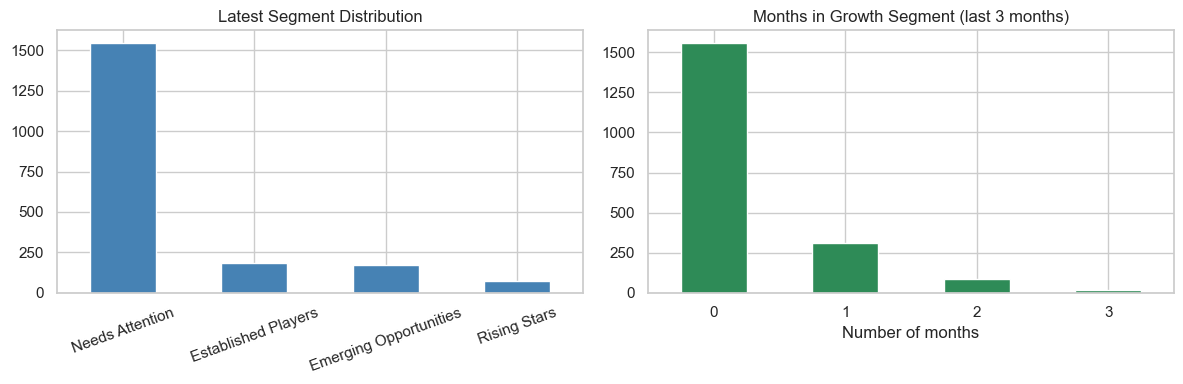

In [5]:
latest_month   = agg['year_month'].max()
lookback_start = latest_month - pd.DateOffset(months=LOOKBACK_MONTHS - 1)

trailing = agg[agg['year_month'] >= lookback_start].copy()
trailing['is_growth_segment'] = trailing['segment'].isin(GROWTH_SEGMENTS).astype(int)

stability = (
    trailing.groupby('name')
    .agg(
        growth_months   =('is_growth_segment', 'sum'),
        months_observed =('year_month',        'nunique'),
        latest_segment  =('segment',           'last'),
    )
    .reset_index()
)

stability['is_stable_growth'] = stability['growth_months'] >= MIN_GROWTH_MONTHS

print(f'Restaurants with stable growth : {stability["is_stable_growth"].sum():,}')
print(f'Latest segment distribution:')
print(stability['latest_segment'].value_counts())

# Visualise stability
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

stability['latest_segment'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Latest Segment Distribution')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)

stability['growth_months'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title(f'Months in Growth Segment (last {LOOKBACK_MONTHS} months)')
axes[1].set_xlabel('Number of months')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 5) Build Latest Snapshot

In [6]:
latest = (
    agg.sort_values('year_month')
    .groupby('name')
    .tail(1)
    .copy()
)

latest = latest.merge(
    stability[['name', 'growth_months', 'months_observed', 'is_stable_growth', 'latest_segment']],
    on='name',
    how='left'
)

print(f'Latest snapshot: {len(latest):,} restaurants')
latest[['name', 'score_perf', 'score_growth', 'latest_segment', 'growth_months', 'is_stable_growth']].head(5)

Latest snapshot: 2,808 restaurants


,name,score_perf,score_growth,latest_segment,growth_months,is_stable_growth
0,Earw Thai Suki Boran Mega Bangna,0.259776,0.2302,NaN,NaN,NaN
1,Fak Marum Pathum Thani,0.167749,0.2302,NaN,NaN,NaN
2,Sakae The PARQ,0.269148,0.2302,NaN,NaN,NaN
3,HUI Suki Ratchaphruek,0.156687,0.2302,NaN,NaN,NaN
4,Hey!Beanstro,0.339068,0.2302,NaN,NaN,NaN


## 6) Load & Aggregate Marketing Performance

Marketing lift is aggregated from activity level â†’ restaurant level.
Restaurants without any campaigns will have `NaN` for all marketing columns â€” they are NOT excluded.

In [7]:
mkt = pd.read_csv(MARKETING_PATH)
mkt['restaurant_id'] = pd.to_numeric(mkt['restaurant_id'], errors='coerce')
mkt['activity_start'] = pd.to_datetime(mkt['activity_start'], errors='coerce')
mkt['activity_end']   = pd.to_datetime(mkt['activity_end'],   errors='coerce')

print(f'Marketing activities : {len(mkt):,}')
print(f'Restaurants covered  : {mkt["restaurant_id"].nunique():,}')
print(f'Channels             : {mkt["channel"].unique()}')
mkt.head(3)

Marketing activities : 1,206
Restaurants covered  : 380
Channels             : ['CRM' 'FB' 'KOL']


,activity_id,bookings_during,bookings_baseline,lift,channel,restaurant_id,activity_start,activity_end,window_hours,crm_campaign_name,...,fb_campaign,fb_amount_spent_thb,window_days,lift_per_day,cost_per_incremental_booking,total_campaign_revenue,aov_thb,incremental_revenue_thb,roi,roi_percentage
0,CRM_005dde7ddbe8,4.0,3.0,1.0,CRM,3316.0,2025-03-02,2025-03-04,48.0,TH_BKK_ctnoti_netcore_group_N_N_active_2025030...,...,NaN,0.0,2.0,0.5,NaN,88400.0,22100.0,22100.0,NaN,NaN
1,CRM_00e026f097bf,2.0,0.0,2.0,CRM,3122.0,2025-09-26,2025-09-28,48.0,TH_BKK_ctnoti_netcore_single_N_N_active_202509...,...,NaN,0.0,2.0,1.0,NaN,93950.0,46975.0,93950.0,NaN,NaN
2,CRM_01166ffb3fba,2.0,2.0,0.0,CRM,5828.0,2025-06-24,2025-06-26,48.0,TH_BKK_ctnoti_netcore_single_N_N_active_202506...,...,NaN,0.0,2.0,0.0,NaN,136488.0,68244.0,0.0,NaN,NaN


In [8]:
# ── Seasonality-adjusted lift baseline ───────────────────────────────────────
# Standard baseline: same duration immediately BEFORE campaign start
# YoY baseline    : same window one year prior (removes seasonal patterns)
#
# We compute BOTH and use YoY where prior-year bookings data exists.
# The priority scoring notebook uses avg_lift_per_day which is computed
# in compare_bookings_with_marketing.ipynb. Here we flag which activities
# have a viable YoY window so the scoring can weight them appropriately.

mkt['window_days'] = (mkt['activity_end'] - mkt['activity_start']).dt.days.clip(lower=1)

# YoY baseline window (same campaign window, one year prior)
mkt['yoy_baseline_start'] = mkt['activity_start'] - pd.DateOffset(years=1)
mkt['yoy_baseline_end']   = mkt['activity_end']   - pd.DateOffset(years=1)

# Flag: does this activity have a plausible YoY window?
# Campaigns starting at or after this cutoff have 12+ months of prior booking data.
YOY_CUTOFF = pd.Timestamp('2025-01-01')
mkt['has_yoy_baseline'] = mkt['activity_start'] >= YOY_CUTOFF

print(f"Activities with YoY baseline available : {mkt['has_yoy_baseline'].sum():,}")
print(f"Activities using standard baseline     : {(~mkt['has_yoy_baseline']).sum():,}")

# ── Aggregate to restaurant level ─────────────────────────────────────────────
rest_mkt = (
    mkt.groupby('restaurant_id')
    .agg(
        n_campaigns            = ('activity_id',             'nunique'),
        avg_lift_per_day       = ('lift_per_day',            'mean'),
        total_incremental_rev  = ('incremental_revenue_thb', 'sum'),
        avg_roi                = ('roi',                     'mean'),
        n_positive_lift        = ('lift', lambda x: (x > 0).sum()),
        n_negative_lift        = ('lift', lambda x: (x < 0).sum()),
        channels_used          = ('channel', lambda x: '+'.join(sorted(x.dropna().unique()))),
        n_yoy_campaigns        = ('has_yoy_baseline',        'sum'),
    )
    .reset_index()
)

# Proportion of campaigns using the more reliable YoY baseline
rest_mkt['pct_yoy_baseline'] = (
    rest_mkt['n_yoy_campaigns'] / rest_mkt['n_campaigns']
).round(2)

# ── lift_reliability: 0.6–1.0 composite based on baseline quality ─────────────
# Rewards restaurants where most campaigns used the seasonality-adjusted YoY
# baseline and had a positive lift signal.
#   pct_yoy_baseline → 0–1 weight on baseline quality  (60% of score)
#   positive lift rate → 0–1 signal confidence          (40% of score)
rest_mkt['positive_lift_rate'] = (
    rest_mkt['n_positive_lift'] /
    (rest_mkt['n_positive_lift'] + rest_mkt['n_negative_lift']).replace(0, np.nan)
).fillna(0.5)  # no lift data → neutral 0.5

rest_mkt['lift_reliability'] = (
    rest_mkt['pct_yoy_baseline']  * 0.60 +
    rest_mkt['positive_lift_rate'] * 0.40
).round(3)
# Clip to [0.0, 1.0] in case of edge values
rest_mkt['lift_reliability'] = rest_mkt['lift_reliability'].clip(0.0, 1.0)

# Best channel = channel with highest avg lift_per_day for this restaurant
best_ch = (
    mkt.groupby(['restaurant_id', 'channel'])['lift_per_day']
    .mean()
    .reset_index()
    .sort_values('lift_per_day', ascending=False)
    .drop_duplicates('restaurant_id')
    .rename(columns={'channel': 'best_channel', 'lift_per_day': 'best_channel_avg_lift'})
)

rest_mkt = rest_mkt.merge(
    best_ch[['restaurant_id', 'best_channel', 'best_channel_avg_lift']],
    on='restaurant_id', how='left'
)

print(f'\nRestaurants with marketing history: {len(rest_mkt):,}')
print(f'lift_reliability range: {rest_mkt["lift_reliability"].min():.2f} – {rest_mkt["lift_reliability"].max():.2f}')
rest_mkt.head(3)


Activities with YoY baseline available : 1,204
Activities using standard baseline     : 2

Restaurants with marketing history: 380
lift_reliability range: 0.60 – 1.00


,restaurant_id,n_campaigns,avg_lift_per_day,total_incremental_rev,avg_roi,n_positive_lift,n_negative_lift,channels_used,n_yoy_campaigns,pct_yoy_baseline,positive_lift_rate,lift_reliability,best_channel,best_channel_avg_lift
0,33.0,1,-1.50,0.000000e+00,NaN,0,1,CRM,1,1.0,0.0,0.6,CRM,-1.50
1,220.0,2,0.40,2.050000e+02,NaN,1,1,KOL,2,1.0,0.5,0.8,KOL,0.40
2,222.0,4,3.25,1.043174e+06,NaN,4,0,CRM,4,1.0,1.0,1.0,CRM,3.25


In [9]:
rest_mkt

,restaurant_id,n_campaigns,avg_lift_per_day,total_incremental_rev,avg_roi,n_positive_lift,n_negative_lift,channels_used,n_yoy_campaigns,pct_yoy_baseline,positive_lift_rate,lift_reliability,best_channel,best_channel_avg_lift
0,33.0,1,-1.500000,0.000000e+00,NaN,0,1,CRM,1,1.0,0.000000,0.600,CRM,-1.500000
1,220.0,2,0.400000,2.050000e+02,NaN,1,1,KOL,2,1.0,0.500000,0.800,KOL,0.400000
2,222.0,4,3.250000,1.043174e+06,NaN,4,0,CRM,4,1.0,1.000000,1.000,CRM,3.250000
3,280.0,5,0.300000,-1.356403e+05,NaN,2,3,CRM+KOL,5,1.0,0.400000,0.760,CRM,1.166667
4,370.0,11,4.063636,2.413865e+06,NaN,7,4,CRM+KOL,11,1.0,0.636364,0.855,CRM,4.750000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,6470.0,1,-0.400000,0.000000e+00,NaN,0,1,KOL,1,1.0,0.000000,0.600,KOL,-0.400000
376,6483.0,1,2.000000,2.032800e+05,NaN,1,0,CRM,1,1.0,1.000000,1.000,CRM,2.000000
377,6501.0,1,0.500000,2.136000e+04,NaN,1,0,CRM,1,1.0,1.000000,1.000,CRM,0.500000
378,6548.0,1,0.200000,2.157600e+04,NaN,1,0,KOL,1,1.0,1.000000,1.000,KOL,0.200000


## 7) Join Momentum + Marketing

Left join the 251 stable-growth restaurants with marketing performance data.
- Restaurants **with** marketing history get lift and ROI columns populated.
- Restaurants **without** marketing history get NaN for those columns â€” they are NOT excluded.

In [10]:
if 'restaurant_id' not in latest.columns:
    print('WARNING: restaurant_id not in momentum snapshot.')
    print('Fix: add restaurant_id to groupby in momentum.ipynb Cell 20, then re-run.')
    combined = latest.copy()
    combined['has_marketing'] = False
else:
    combined = latest.merge(rest_mkt, on='restaurant_id', how='left')
    combined['has_marketing'] = combined['n_campaigns'].notna()

# Ensure all marketing columns exist even if no rows matched the join
marketing_col_defaults = {
    'avg_lift_per_day'      : np.nan,
    'total_incremental_rev' : np.nan,
    'avg_roi'               : np.nan,
    'n_positive_lift'       : 0,
    'n_negative_lift'       : 0,
    'channels_used'         : np.nan,
    'best_channel'          : np.nan,
    'best_channel_avg_lift' : np.nan,
    'n_campaigns'           : np.nan,
}
for col, default in marketing_col_defaults.items():
    if col not in combined.columns:
        combined[col] = default

print(f'Total restaurants (post-join)     : {len(combined):,}')
print(f'With marketing history            : {combined["has_marketing"].sum():,}')
print(f'Without marketing history         : {(~combined["has_marketing"]).sum():,}')

Total restaurants (post-join)     : 2,808
With marketing history            : 380
Without marketing history         : 2,428


In [11]:
# Sanity check â€” confirm join result
print('Combined shape:', combined.shape)
print('Columns:', combined.columns.tolist())
print()

# Diagnose if restaurant_id overlap is low
if 'restaurant_id' in combined.columns:
    momentum_ids  = set(latest['restaurant_id'].dropna().astype(int))
    marketing_ids = set(mkt['restaurant_id'].dropna().astype(int))
    print(f'Momentum restaurant IDs  : {len(momentum_ids):,}')
    print(f'Marketing restaurant IDs : {len(marketing_ids):,}')
    print(f'Overlap                  : {len(momentum_ids & marketing_ids):,}')

Combined shape: (2808, 62)
Columns: ['restaurant_id', 'name', 'year_month', 'monthly_bookings', 'monthly_gmv', 'avg_gmv_per_booking', 'avg_guests', 'active_days', 'in_analysis_window', 'booking_growth_mom', 'gmv_growth_mom', 'bookings_prior_year', 'gmv_prior_year', 'booking_growth_yoy', 'gmv_growth_yoy', 'months_of_history', 'has_full_year', 'booking_growth_mom_rolling', 'gmv_growth_mom_rolling', 'booking_growth_yoy_rolling', 'gmv_growth_yoy_rolling', 'growth_signal_used', 'booking_growth_rolling', 'gmv_growth_rolling', 'log_bookings', 'log_gmv', 'score_perf', 'growth_rate_blended', 'score_growth', 'score_growth_mom', 'score_growth_yoy', 'is_seasonal', 'booking_growth_rolling_prev', 'gmv_growth_rolling_prev', 'log_bookings_prev', 'log_gmv_prev', 'delta_growth_book', 'delta_growth_rev', 'delta_size_book', 'delta_size_rev', 'monthly_revenue', 'revenue_growth_rolling', 'revenue_growth_yoy', 'segment', 'growth_months', 'months_observed', 'is_stable_growth', 'latest_segment', 'n_campaigns',

## 8) Priority Score

Growth-only composite. `score_growth` arrives pre-computed from the momentum notebook
with a single normalisation across the full portfolio, so YoY and MoM restaurants
are already on the same scale.

```
growth_component = score_growth_norm Ã— 0.60 + delta_growth_norm Ã— 0.40
priority_score   = min_max_norm(growth_component) Ã— 100
```

Seasonal restaurants are included â€” tagged in `priority_tier` and `is_seasonal`.

In [12]:
# â”€â”€ Filter to stable-growth universe â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
priority_df = combined[combined['is_stable_growth'] == True].copy()
print(f'Working universe (stable growth): {len(priority_df):,}')
print(f'  With marketing history        : {priority_df["has_marketing"].sum():,}')
print(f'  Without marketing history     : {(~priority_df["has_marketing"]).sum():,}')

if 'is_seasonal' not in priority_df.columns:
    priority_df['is_seasonal'] = False
seasonal_col = priority_df['is_seasonal']
print(f'  Seasonal-flagged              : {seasonal_col.sum():,}')

if 'growth_signal_used' not in priority_df.columns:
    priority_df['growth_signal_used'] = 'MoM'

print(f'\nGrowth signal used:')
print(priority_df['growth_signal_used'].value_counts())

# â”€â”€ Acceleration (delta) component â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
delta_col = 'delta_growth_book' if 'delta_growth_book' in priority_df.columns else None
if delta_col:
    priority_df['delta_growth_norm'] = min_max_norm(priority_df[delta_col].fillna(0))
else:
    priority_df['delta_growth_norm'] = 0.0
    print('WARNING: delta_growth_book not found â€” acceleration set to 0.')

# â”€â”€ score_growth is already on a single normalised scale from the momentum nb â”€
# No re-normalisation needed before blending with delta â€” both are [0, 1]
priority_df['score_growth_norm'] = min_max_norm(priority_df['score_growth'].fillna(0))

# â”€â”€ Growth component (60% score, 40% acceleration) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
priority_df['growth_component'] = (
    priority_df['score_growth_norm'] * W_SCORE_GROWTH +
    priority_df['delta_growth_norm'] * W_DELTA_GROWTH
)

# â”€â”€ Priority score: normalise growth_component to 0â€“100 â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
priority_df['priority_score'] = min_max_norm(priority_df['growth_component']) * 100

print('\nPriority score distribution:')
print(priority_df['priority_score'].describe().round(2))
print('\nTop 5:')
print(priority_df.nlargest(5, 'priority_score')[['name', 'priority_score', 'growth_signal_used', 'is_seasonal']].to_string(index=False))


Working universe (stable growth): 20
  With marketing history        : 10
  Without marketing history     : 10
  Seasonal-flagged              : 1

Growth signal used:
growth_signal_used
MoM    17
YoY     3
Name: count, dtype: int64

Priority score distribution:
count     20.00
mean      30.58
std       22.88
min        0.00
25%       16.74
50%       22.26
75%       40.50
max      100.00
Name: priority_score, dtype: float64

Top 5:
                                                          name  priority_score growth_signal_used  is_seasonal
                            Beef Express Muangthong Nonthaburi      100.000000                YoY        False
                                           Chakrabongse Villas       56.610904                MoM        False
Brewski Rooftop Sports Bar Radisson Blu Plaza Bangkok (Indoor)       55.221024                MoM        False
                              Ramen Kaosoi and Japanese Buffet       53.027829                MoM        False
         

## 9) Assign Priority Tier & Recommended Channel

Two simple tiers within the 251 stable-growth restaurants:
- ðŸ”´ **Activate â€” proven marketing response**: has marketing history and positive lift
- ðŸŸ  **Activate â€” untapped, no prior spend**: no marketing history, growing organically

In [13]:
# â”€â”€ Priority tier label â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
priority_df['priority_tier'] = np.where(
    priority_df['has_marketing'] & (priority_df['avg_lift_per_day'].fillna(0) > 0),
    'ðŸ”´ Activate â€” proven marketing response',
    np.where(
        ~priority_df['has_marketing'],
        'ðŸŸ  Activate â€” untapped, no prior spend',
        'ðŸŸ¡ Activate â€” review channel strategy'
    )
)

# Append seasonal tag â€” does not change tier, adds timing context
if 'is_seasonal' in priority_df.columns:
    priority_df['priority_tier'] = np.where(
        priority_df['is_seasonal'],
        priority_df['priority_tier'] + ' ðŸŒŠ Seasonal',
        priority_df['priority_tier']
    )

priority_df['recommended_channel'] = priority_df.apply(recommend_channel, axis=1)

print('Priority tier distribution:')
print(priority_df['priority_tier'].value_counts())

Priority tier distribution:
priority_tier
ðŸŸ  Activate â€” untapped, no prior spend                  9
ðŸ”´ Activate â€” proven marketing response                 6
ðŸŸ¡ Activate â€” review channel strategy                   4
ðŸŸ  Activate â€” untapped, no prior spend ðŸŒŠ Seasonal    1
Name: count, dtype: int64


## 10) Final Ranked Output

Ranked list of the ~251 stable-growth restaurants, sorted by priority score descending.

In [14]:
output_cols = [
    'name', 'restaurant_id',
    'priority_score', 'priority_tier', 'recommended_channel',
    'latest_segment', 'growth_months', 'months_observed', 'is_stable_growth',
    'score_perf', 'score_growth',
    'monthly_bookings', 'monthly_revenue',          # monthly_revenue = monthly_gmv alias
    'booking_growth_rolling', 'revenue_growth_rolling',  # revenue_growth_rolling = gmv alias
    'booking_growth_yoy', 'revenue_growth_yoy',     # revenue_growth_yoy = gmv_growth_yoy alias
    'growth_rate_blended',
    'growth_signal_used',
    'score_growth_mom', 'score_growth_yoy',
    'is_seasonal',
    'has_full_year',
    'delta_growth_book', 'delta_growth_rev',
    'has_marketing', 'n_campaigns',
    'avg_lift_per_day', 'total_incremental_rev',
    'avg_roi', 'n_positive_lift', 'n_negative_lift',
    'pct_yoy_baseline',
    'lift_reliability',                              # computed in Cell 15
    'channels_used', 'best_channel',
]

output_cols = [c for c in output_cols if c in priority_df.columns]

priority_list = (
    priority_df[output_cols]
    .sort_values('priority_score', ascending=False)
    .reset_index(drop=True)
)
priority_list.index += 1
priority_list.index.name = 'rank'

priority_list.to_csv(OUTPUT_PATH)

# ── Save segment labels parquet ───────────────────────────────────────────────
# Uses the latest snapshot (one row per restaurant) with key momentum columns.
# 'name' is included if present; falls back gracefully if not.
segment_base_cols = ['restaurant_id', 'latest_segment', 'score_perf', 'score_growth', 'year_month']
if 'name' in latest.columns:
    segment_base_cols = ['restaurant_id', 'name'] + segment_base_cols[1:]
segment_cols = [c for c in segment_base_cols if c in latest.columns]

segment_labels = (
    latest[segment_cols]
    .sort_values('restaurant_id')
    .drop_duplicates('restaurant_id', keep='last')
    .reset_index(drop=True)
)
segment_labels.to_parquet(SEGMENT_OUTPUT_PATH, index=False)
print(f'Saved segment labels → {SEGMENT_OUTPUT_PATH} ({len(segment_labels):,} restaurants)')

print(f'Saved → {OUTPUT_PATH}')
print(f'Total restaurants ranked: {len(priority_list):,}')

if 'growth_signal_used' in priority_list.columns:
    print(f'\nGrowth signal used in final ranked list:')
    print(priority_list['growth_signal_used'].value_counts())

priority_list.head(10)


Saved segment labels → ..\_2_feature_engineering+momentum\start\priority_latest_momentum_labels.parquet (2,808 restaurants)
Saved → priority_list.csv
Total restaurants ranked: 20

Growth signal used in final ranked list:
growth_signal_used
MoM    17
YoY     3
Name: count, dtype: int64


,name,restaurant_id,priority_score,priority_tier,recommended_channel,latest_segment,growth_months,months_observed,is_stable_growth,score_perf,...,n_campaigns,avg_lift_per_day,total_incremental_rev,avg_roi,n_positive_lift,n_negative_lift,pct_yoy_baseline,lift_reliability,channels_used,best_channel
rank,,,,,,,,,,,,,,,,,,,,,
1,Beef Express Muangthong Nonthaburi,3181,100.000000,ðŸ”´ Activate â€” proven marketing response,CRM,Rising Stars,3.0,3.0,True,0.689532,...,6.0,0.654762,127619.206349,-479.492793,4.0,2.0,1.0,0.867,CRM+FB,CRM
2,Chakrabongse Villas,6049,56.610904,ðŸ”´ Activate â€” proven marketing response,KOL,Rising Stars,3.0,3.0,True,0.515169,...,1.0,0.200000,19176.000000,NaN,1.0,0.0,1.0,1.000,KOL,KOL
3,Brewski Rooftop Sports Bar Radisson Blu Plaza ...,1065,55.221024,"ðŸŸ Activate â€” untapped, no prior spend",FB,Emerging Opportunities,3.0,3.0,True,0.396419,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Ramen Kaosoi and Japanese Buffet,6097,53.027829,ðŸŸ¡ Activate â€” review channel strategy,KOL,Rising Stars,3.0,3.0,True,0.542442,...,1.0,0.000000,0.000000,NaN,0.0,0.0,1.0,0.800,KOL,KOL
5,Blue Elephant Sathorn,6206,40.591597,"ðŸŸ Activate â€” untapped, no prior spend",KOL,Rising Stars,3.0,3.0,True,0.561749,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Shabu Square At For You Park Bangna,4990,40.467412,ðŸ”´ Activate â€” proven marketing response,CRM,Rising Stars,3.0,3.0,True,0.526458,...,4.0,4.775000,506217.816419,NaN,3.0,1.0,1.0,0.900,CRM+KOL,CRM
7,Tap Yard,4781,38.758685,"ðŸŸ Activate â€” untapped, no prior spend",FB,Emerging Opportunities,3.0,3.0,True,0.359515,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Red Sky Restaurant 55th Floor,2909,33.067264,ðŸŸ¡ Activate â€” review channel strategy,KOL,Rising Stars,3.0,3.0,True,0.578429,...,1.0,-0.500000,0.000000,NaN,0.0,1.0,1.0,0.600,CRM,CRM
9,Tu Bar Rooftop at Sri Panwa (Phuket),3882,28.405604,"ðŸŸ Activate â€” untapped, no prior spend",KOL,Rising Stars,3.0,3.0,True,0.715523,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 11) Visualisations

=== PRIORITY TIER SUMMARY ===
                                                          count  avg_score  avg_growth
priority_tier                                                                         
ðŸ”´ Activate â€” proven marketing response                   6     37.251       0.600
ðŸŸ¡ Activate â€” review channel strategy                     4     32.006       0.576
ðŸŸ  Activate â€” untapped, no prior spend                    9     27.121       0.579
ðŸŸ  Activate â€” untapped, no prior spend ðŸŒŠ Seasonal      1     16.064       0.511


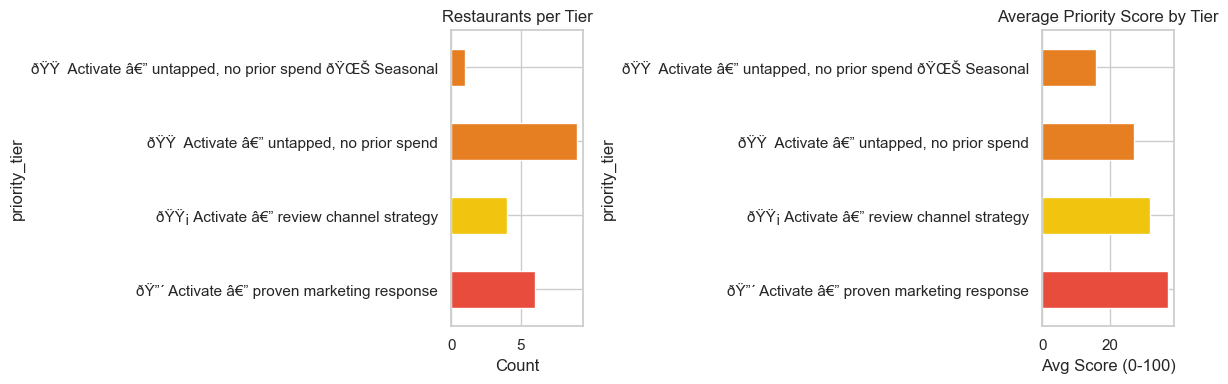

In [15]:
# ── Tier breakdown ────────────────────────────────────────────────────────────
tier_summary = (
    priority_list.groupby('priority_tier')
    .agg(
        count      =('priority_score', 'count'),
        avg_score  =('priority_score', 'mean'),
        avg_growth =('score_growth',   'mean'),
    )
    .round(3)
    .sort_values('avg_score', ascending=False)
)

print('=== PRIORITY TIER SUMMARY ===')
print(tier_summary.to_string())

TIER_COLOR_MAP = {
    'proven marketing response' : '#e74c3c',
    'untapped'                  : '#e67e22',
    'review channel'            : '#f1c40f',
}

def tier_colors(index):
    """Map tier labels to colors, falling back to grey for unknowns."""
    colors = []
    for label in index:
        match = next((v for k, v in TIER_COLOR_MAP.items() if k in label), '#95a5a6')
        colors.append(match)
    return colors

colors = tier_colors(tier_summary.index)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

tier_summary['count'].plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Restaurants per Tier')
axes[0].set_xlabel('Count')

tier_summary['avg_score'].plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('Average Priority Score by Tier')
axes[1].set_xlabel('Avg Score (0-100)')

plt.tight_layout()
plt.show()

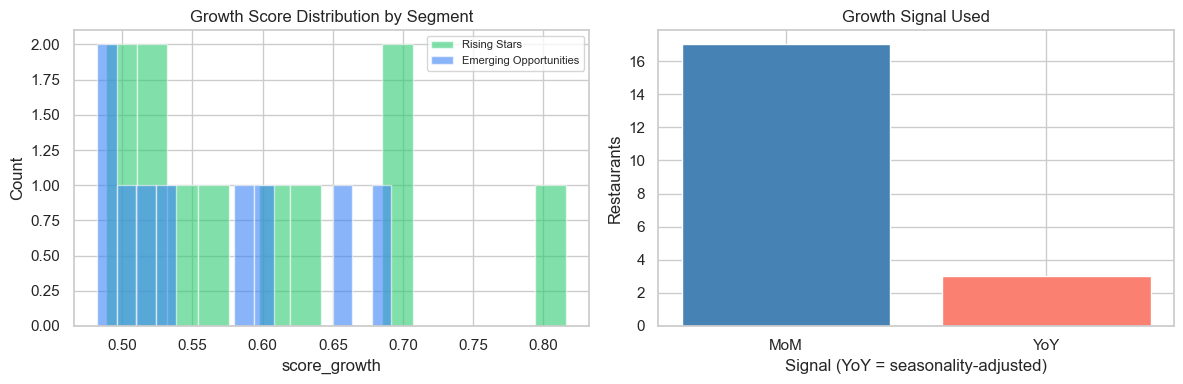

In [16]:
# â”€â”€ Growth score distribution across tiers â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for tier, color in [
    ('Rising Stars', '#2ecc71'),
    ('Emerging Opportunities', '#3b82f6'),
    ('Established Players', '#9b59b6'),
    ('Needs Attention', '#e74c3c'),
]:
    sub = priority_list[priority_list['latest_segment'] == tier]['score_growth'].dropna()
    if len(sub):
        axes[0].hist(sub, bins=15, alpha=0.6, color=color, label=tier)

axes[0].set_title('Growth Score Distribution by Segment')
axes[0].set_xlabel('score_growth')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)

# Growth signal used (YoY vs MoM)
if 'growth_signal_used' in priority_list.columns:
    sig = priority_list['growth_signal_used'].value_counts()
    axes[1].bar(sig.index, sig.values, color=['steelblue', 'salmon'])
    axes[1].set_title('Growth Signal Used')
    axes[1].set_ylabel('Restaurants')
    axes[1].set_xlabel('Signal (YoY = seasonality-adjusted)')

plt.tight_layout()
plt.show()

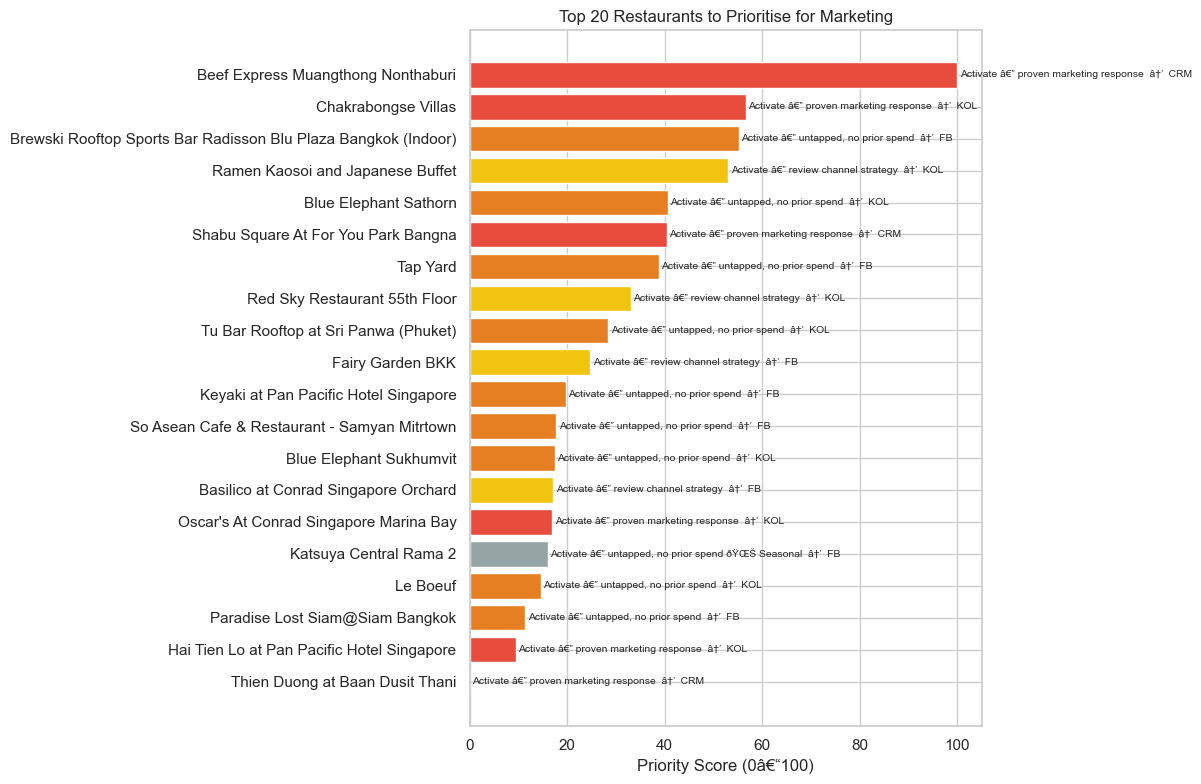

In [17]:
# â”€â”€ Top 20 priority restaurants â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
top20 = priority_list.head(20).copy()

tier_colors = {
    'ðŸ”´ Activate â€” proven marketing response' : '#e74c3c',
    'ðŸŸ  Activate â€” untapped, no prior spend'  : '#e67e22',
    'ðŸŸ¡ Activate â€” review channel strategy'   : '#f1c40f',
}
colors = top20['priority_tier'].map(tier_colors).fillna('#95a5a6')

plt.figure(figsize=(12, 8))
bars = plt.barh(top20['name'], top20['priority_score'], color=colors)
plt.xlabel('Priority Score (0â€“100)')
plt.title('Top 20 Restaurants to Prioritise for Marketing')
plt.gca().invert_yaxis()

for bar, (_, row) in zip(bars, top20.iterrows()):
    label = f"{row['priority_tier']}  â†’  {row.get('recommended_channel', '')}".replace('ðŸ”´ ', '').replace('ðŸŸ  ', '').replace('ðŸŸ¡ ', '')
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        label,
        va='center', fontsize=7.5
    )

plt.tight_layout()
plt.show()

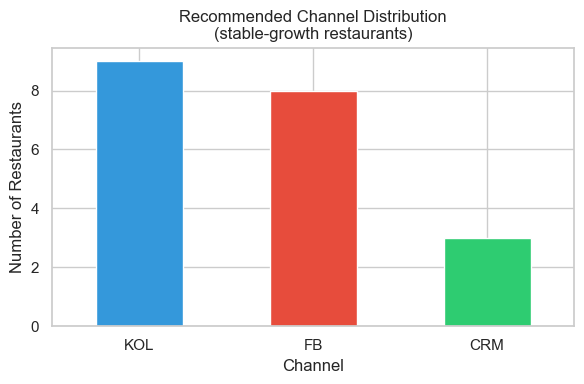

In [18]:
# â”€â”€ Recommended channel distribution â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ch_counts = priority_list['recommended_channel'].value_counts()

plt.figure(figsize=(6, 4))
ch_counts.plot(kind='bar', color=['#3498db', '#e74c3c', '#2ecc71'])
plt.title('Recommended Channel Distribution\n(stable-growth restaurants)')
plt.xlabel('Channel')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

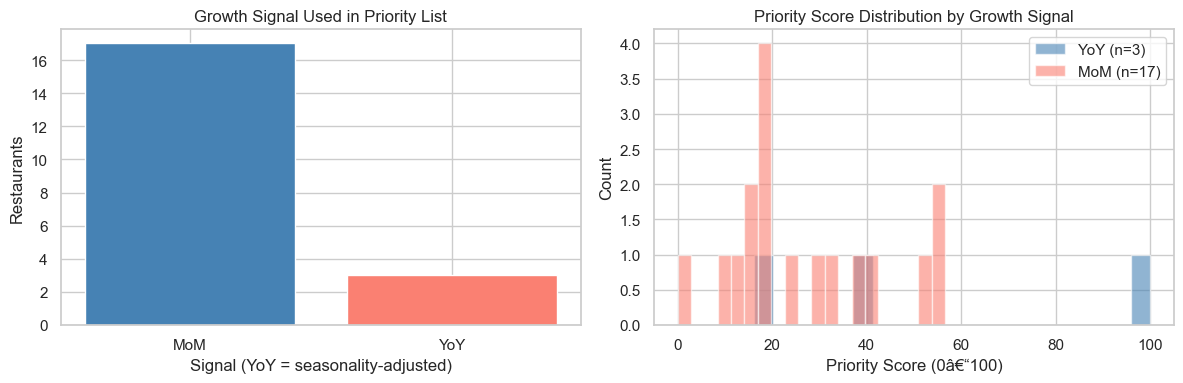

In [19]:
# â”€â”€ Seasonality transparency: YoY vs MoM in the priority list â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
if 'growth_signal_used' in priority_list.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Signal used breakdown
    signal_counts = priority_list['growth_signal_used'].value_counts()
    axes[0].bar(signal_counts.index, signal_counts.values, color=['steelblue', 'salmon'])
    axes[0].set_title('Growth Signal Used in Priority List')
    axes[0].set_ylabel('Restaurants')
    axes[0].set_xlabel('Signal (YoY = seasonality-adjusted)')

    # Score distribution by signal type
    for sig, color in [('YoY', 'steelblue'), ('MoM', 'salmon')]:
        subset = priority_list[priority_list['growth_signal_used'] == sig]['priority_score']
        if len(subset):
            axes[1].hist(subset, bins=20, alpha=0.6, color=color, label=f'{sig} (n={len(subset)})')
    axes[1].set_title('Priority Score Distribution by Growth Signal')
    axes[1].set_xlabel('Priority Score (0â€“100)')
    axes[1].set_ylabel('Count')
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print('growth_signal_used column not found â€” re-run momentum_seasonality.ipynb first.')

## 12) Summary Table

Final actionable summary â€” one row per tier with key averages.

In [20]:
summary = (
    priority_list.groupby('priority_tier')
    .agg(
        n_restaurants        =('name',                'count'),
        avg_priority_score   =('priority_score',      'mean'),
        avg_growth_score     =('score_growth',        'mean'),
        avg_monthly_bookings =('monthly_bookings',    'mean'),
        top_channel          =('recommended_channel', lambda x: x.value_counts().index[0]),
    )
    .round(2)
    .sort_values('avg_priority_score', ascending=False)
)

print('=== FINAL SUMMARY ===')
summary

=== FINAL SUMMARY ===


,n_restaurants,avg_priority_score,avg_growth_score,avg_monthly_bookings,top_channel
priority_tier,,,,,
ðŸ”´ Activate â€” proven marketing response,6,37.25,0.60,43.00,CRM
ðŸŸ¡ Activate â€” review channel strategy,4,32.01,0.58,21.00,KOL
"ðŸŸ Activate â€” untapped, no prior spend",9,27.12,0.58,27.67,FB
"ðŸŸ Activate â€” untapped, no prior spend ðŸŒŠ Seasonal",1,16.06,0.51,6.00,FB
